Analyse Diabetes Datensatz ausgeführt auf Windows Rechner mit Intel

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('emissions_full_DT_Intel.csv')

# Ermnitteln der Anzahl von kategorischen und numerischen Features

In [3]:
# Definieren der Feature Typen
feature_types = {
    'Diabetes_binary': 'kategorisch',
    'HighBP': 'kategorisch',
    'HighChol': 'kategorisch',
    'CholCheck': 'kategorisch',
    'BMI': 'numerisch',
    'Smoker': 'kategorisch',
    'Stroke': 'kategorisch',
    'HeartDiseaseorAttack': 'kategorisch',
    'PhysActivity': 'kategorisch',
    'Fruits': 'kategorisch',
    'Veggies': 'kategorisch',
    'HvyAlcoholConsump': 'kategorisch',
    'AnyHealthcare': 'kategorisch',
    'NoDocbcCost': 'kategorisch',
    'GenHlth': 'numerisch',
    'MentHlth': 'numerisch',
    'PhysHlth': 'numerisch',
    'DiffWalk': 'kategorisch',
    'Sex': 'kategorisch',
    'Age': 'numerisch',
    'Education': 'numerisch',
    'Income': 'numerisch'
}

In [4]:
#df = combined_df

df['num_num_features'] = df['feature_names'].apply(lambda x: sum(1 for feature in x.split(', ') if feature_types.get(feature) == 'numerisch'))
df['num_cat_features'] = df['feature_names'].apply(lambda x: sum(1 for feature in x.split(', ') if feature_types.get(feature) == 'kategorisch'))

In [5]:
df.head()

,timestamp,project_name,run_id,duration,emissions,emissions_rate,cpu_power,gpu_power,ram_power,cpu_energy,...,latitude,ram_total_size,tracking_mode,on_cloud,pue,num_features,reduction_percentage,feature_names,num_num_features,num_cat_features
0,2023-11-16T18:29:15,DecisionTree_21_features_reduced_by_0_percent0,40fda0de-6f11-41a7-9aa2-e3978bf6859c,1.917529,2.024745e-06,0.000001,7.5,0.0,2.954122,3.976080e-06,...,48.706,7.877659,machine,N,1.0,21,0,"HighChol, Age, Sex, Smoker, Veggies, DiffWalk,...",7,14
1,2023-11-16T18:29:20,DecisionTree_21_features_reduced_by_20_percent0,f094c2d4-ca95-4a58-aa5e-fa87230fa127,1.546919,1.638549e-06,0.000001,7.5,0.0,2.954122,3.222748e-06,...,48.706,7.877659,machine,N,1.0,21,20,"HighChol, Age, Sex, Smoker, Veggies, DiffWalk,...",7,14
2,2023-11-16T18:29:24,DecisionTree_21_features_reduced_by_40_percent0,e13bedb1-57ac-455b-9063-11b6123d4a84,1.105765,1.169812e-06,0.000001,7.5,0.0,2.954122,2.303676e-06,...,48.706,7.877659,machine,N,1.0,21,40,"HighChol, Age, Sex, Smoker, Veggies, DiffWalk,...",7,14
3,2023-11-16T18:29:29,DecisionTree_21_features_reduced_by_60_percent0,6739ed3e-b1a4-4a45-85ff-dbf679e92f30,0.705113,7.456149e-07,0.000001,7.5,0.0,2.954122,1.468986e-06,...,48.706,7.877659,machine,N,1.0,21,60,"HighChol, Age, Sex, Smoker, Veggies, DiffWalk,...",7,14
4,2023-11-16T18:29:32,DecisionTree_21_features_reduced_by_80_percent0,202169c1-745a-42b4-90f2-8818683a9294,0.332121,3.358992e-07,0.000001,7.5,0.0,2.954122,6.593600e-07,...,48.706,7.877659,machine,N,1.0,21,80,"HighChol, Age, Sex, Smoker, Veggies, DiffWalk,...",7,14


In [6]:
# Ermitteln, wie of ein feature vorgekommen ist

df['feature_names'] = df['feature_names'].str.split(', ')

feature_counts = {}

# Iteriere über jede Zeile des DataFrames
for index, row in df.iterrows():
    features = row['feature_names']
    if isinstance(features, list):
        for feature in features:
            if feature in feature_counts:
                feature_counts[feature] += 1
            else:
                feature_counts[feature] = 1


feature_counts_df = pd.DataFrame(list(feature_counts.items()), columns=['Feature', 'Count'])

In [7]:
feature_counts

{'HighChol': 550,
 'Age': 560,
 'Sex': 590,
 'Smoker': 560,
 'Veggies': 575,
 'DiffWalk': 495,
 'GenHlth': 565,
 'AnyHealthcare': 590,
 'Income': 590,
 'CholCheck': 540,
 'MentHlth': 535,
 'BMI': 510,
 'PhysHlth': 550,
 'NoDocbcCost': 580,
 'HighBP': 570,
 'HeartDiseaseorAttack': 495,
 'Education': 515,
 'Stroke': 540,
 'PhysActivity': 590,
 'HvyAlcoholConsump': 535,
 'Fruits': 515}

# Häufigkeit der Features auf Zufälligkeit testen

/usr/local/lib/python3.10/dist-packages/statsmodels/graphics/gofplots.py:1045: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  ax.plot(x, y, fmt, **plot_style)


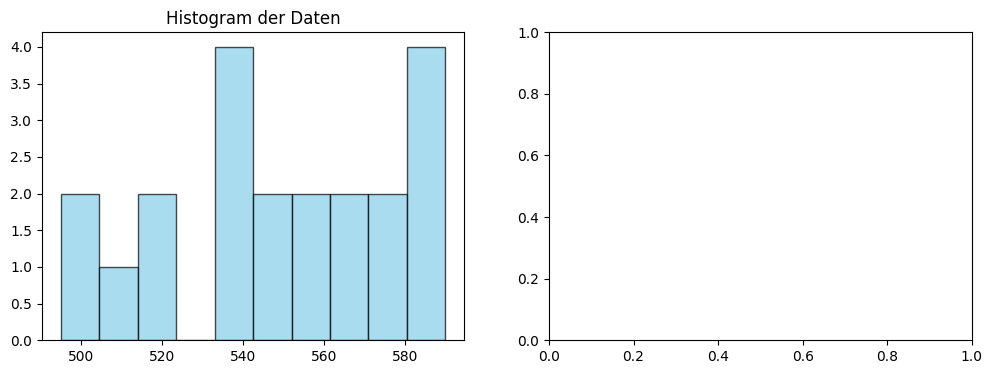

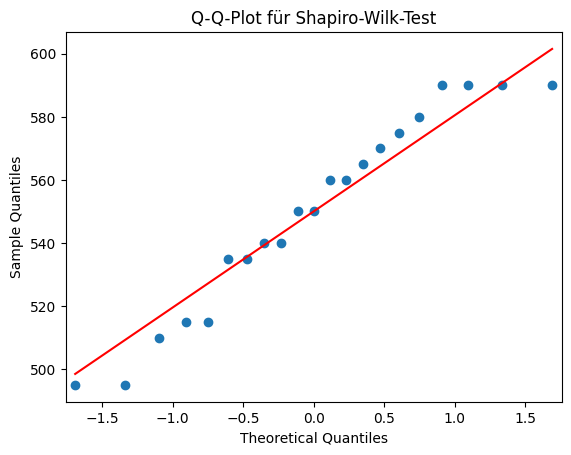

Anderson-Darling-Statistik: 0.39029357710017365
Kritische Werte für Anderson-Darling-Test: [0.508 0.579 0.694 0.81  0.963]
Anderson-Darling-Test: Die Daten zeigen keine signifikante Abweichung von einer Normalverteilung.
Shapiro-Wilk-Statistik: 0.9316322207450867
P-Wert für Shapiro-Wilk-Test: 0.14842121303081512
Shapiro-Wilk-Test: Die Daten zeigen keine signifikante Abweichung von einer Normalverteilung.


In [8]:
import numpy as np
from scipy.stats import anderson, shapiro
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Extrahiere die beobachteten Werte
observed_data = list(feature_counts.values())

# Führe den Anderson-Darling-Test durch
result_anderson = anderson(observed_data)
alpha = 0.05  # Signifikanzniveau

# Führe den Shapiro-Wilk-Test durch
statistic_shapiro, p_value_shapiro = shapiro(observed_data)

# Histogramm
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(observed_data, bins=10, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Histogram der Daten')

# Q-Q-Plot für den Shapiro-Wilk-Test
plt.subplot(1, 2, 2)
sm.qqplot(np.array(observed_data), line='s', color='lightcoral')
plt.title('Q-Q-Plot für Shapiro-Wilk-Test')

plt.show()

# Zeige die Testergebnisse und Interpretation
print(f"Anderson-Darling-Statistik: {result_anderson.statistic}")
print(f"Kritische Werte für Anderson-Darling-Test: {result_anderson.critical_values}")
if result_anderson.statistic > result_anderson.critical_values[2]:
    print("Anderson-Darling-Test: Die Daten weichen signifikant von einer Normalverteilung ab.")
else:
    print("Anderson-Darling-Test: Die Daten zeigen keine signifikante Abweichung von einer Normalverteilung.")

print(f"Shapiro-Wilk-Statistik: {statistic_shapiro}")
print(f"P-Wert für Shapiro-Wilk-Test: {p_value_shapiro}")
if p_value_shapiro < alpha:
    print("Shapiro-Wilk-Test: Die Daten weichen signifikant von einer Normalverteilung ab.")
else:
    print("Shapiro-Wilk-Test: Die Daten zeigen keine signifikante Abweichung von einer Normalverteilung.")

In [9]:
df.head()

,timestamp,project_name,run_id,duration,emissions,emissions_rate,cpu_power,gpu_power,ram_power,cpu_energy,...,latitude,ram_total_size,tracking_mode,on_cloud,pue,num_features,reduction_percentage,feature_names,num_num_features,num_cat_features
0,2023-11-16T18:29:15,DecisionTree_21_features_reduced_by_0_percent0,40fda0de-6f11-41a7-9aa2-e3978bf6859c,1.917529,2.024745e-06,0.000001,7.5,0.0,2.954122,3.976080e-06,...,48.706,7.877659,machine,N,1.0,21,0,"[HighChol, Age, Sex, Smoker, Veggies, DiffWalk...",7,14
1,2023-11-16T18:29:20,DecisionTree_21_features_reduced_by_20_percent0,f094c2d4-ca95-4a58-aa5e-fa87230fa127,1.546919,1.638549e-06,0.000001,7.5,0.0,2.954122,3.222748e-06,...,48.706,7.877659,machine,N,1.0,21,20,"[HighChol, Age, Sex, Smoker, Veggies, DiffWalk...",7,14
2,2023-11-16T18:29:24,DecisionTree_21_features_reduced_by_40_percent0,e13bedb1-57ac-455b-9063-11b6123d4a84,1.105765,1.169812e-06,0.000001,7.5,0.0,2.954122,2.303676e-06,...,48.706,7.877659,machine,N,1.0,21,40,"[HighChol, Age, Sex, Smoker, Veggies, DiffWalk...",7,14
3,2023-11-16T18:29:29,DecisionTree_21_features_reduced_by_60_percent0,6739ed3e-b1a4-4a45-85ff-dbf679e92f30,0.705113,7.456149e-07,0.000001,7.5,0.0,2.954122,1.468986e-06,...,48.706,7.877659,machine,N,1.0,21,60,"[HighChol, Age, Sex, Smoker, Veggies, DiffWalk...",7,14
4,2023-11-16T18:29:32,DecisionTree_21_features_reduced_by_80_percent0,202169c1-745a-42b4-90f2-8818683a9294,0.332121,3.358992e-07,0.000001,7.5,0.0,2.954122,6.593600e-07,...,48.706,7.877659,machine,N,1.0,21,80,"[HighChol, Age, Sex, Smoker, Veggies, DiffWalk...",7,14


# Korrelationen

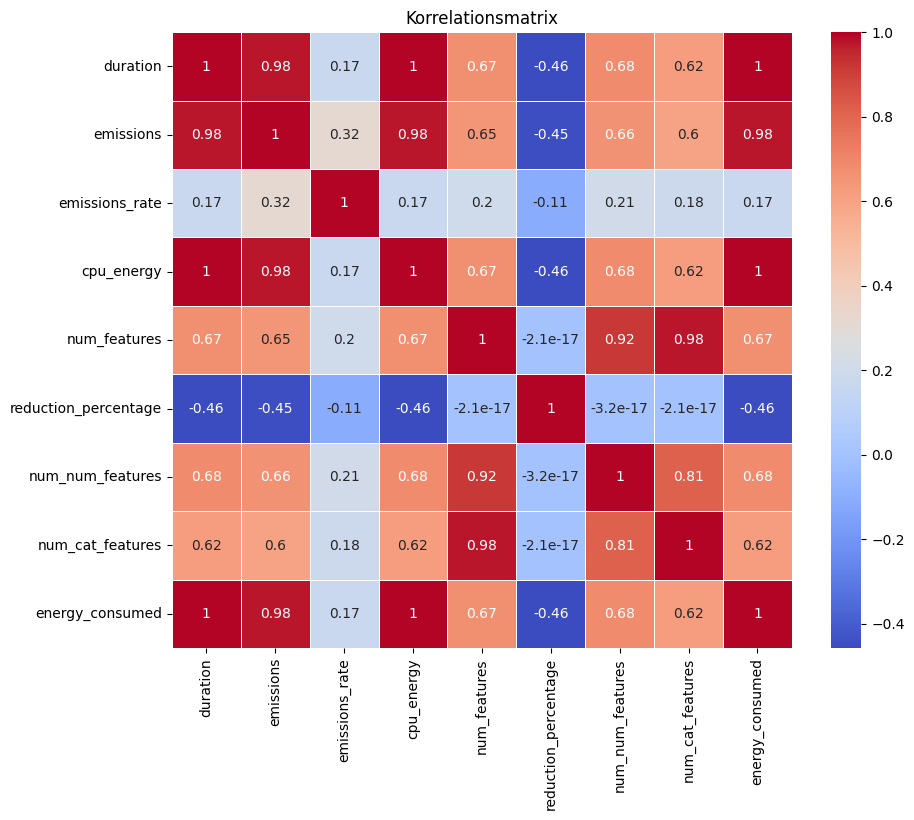

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Spalten definieren, welche behalten werden sollen
selected_columns = ['duration', 'emissions', 'emissions_rate', 'cpu_energy', 'num_features', 'reduction_percentage', 'num_num_features', 'num_cat_features', 'energy_consumed']

# Erstelle die Korrelationsmatrix nur für die ausgewählten Spalten
correlation_matrix = df[selected_columns].corr()

# Erstelle eine Heatmap der Korrelationsmatrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Korrelationsmatrix')
plt.show()

Vergleich von Decision Tree Algorithmus in Google Colab

In [11]:
df_2 = pd.read_csv('emissions_full_Diabetes_DecisionTree.csv')

In [12]:
df_2['num_num_features'] = df_2['feature_names'].apply(lambda x: sum(1 for feature in x.split(', ') if feature_types.get(feature) == 'numerisch'))
df_2['num_cat_features'] = df_2['feature_names'].apply(lambda x: sum(1 for feature in x.split(', ') if feature_types.get(feature) == 'kategorisch'))

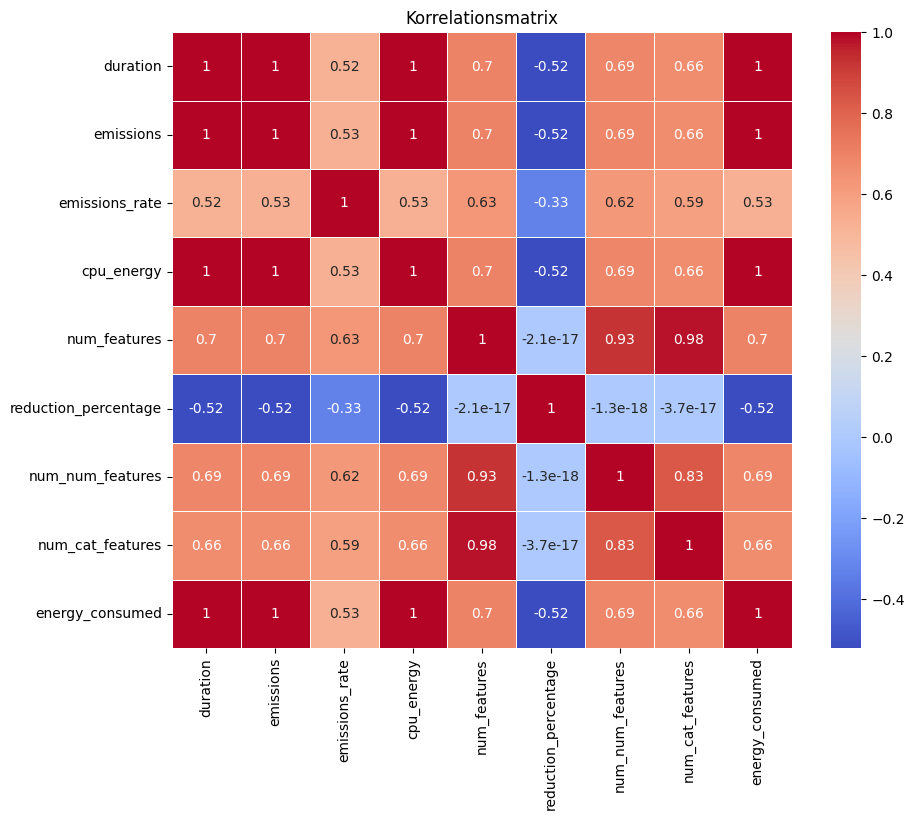

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# Spalten definieren, welche behalten werden sollen
selected_columns = ['duration', 'emissions', 'emissions_rate', 'cpu_energy', 'num_features', 'reduction_percentage', 'num_num_features', 'num_cat_features', 'energy_consumed']

# Erstelle die Korrelationsmatrix nur für die ausgewählten Spalten
correlation_matrix = df_2[selected_columns].corr()

# Erstelle eine Heatmap der Korrelationsmatrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Korrelationsmatrix')
plt.show()